In [15]:
%load_ext autoreload
%autoreload 2

# Set LD_LIBRARY_PATH for cuequivariance_ops
import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import torch

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

import os
import pickle
import re
from tqdm import tqdm
from glob import glob
from copy import deepcopy

from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, auc
from Bio.PDB import MMCIFParser


import esm
# from faesm.esm import FAEsmForMaskedLM

from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks, tok2aa_d
from MSA_Pairformer.plotting import eval_hetero_oligomer


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')
print(f"Using device: {torch.cuda.get_device_name(device)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: NVIDIA GH200 480GB


In [2]:
# File paths
parde_alignment_path = "../../data/Figure3_toxin_antitoxin/ParDE.filt.fas"
fitness_repA_path = "../../data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_A.csv"
fitness_repB_path = "../../data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_B.csv"

# Load fitness data
fitness_repA = pd.read_csv(fitness_repA_path, index_col=None, header=None)
fitness_repB = pd.read_csv(fitness_repB_path, index_col=None, header=None)

# Load WT sequence and chain break index
with open(parde_alignment_path, "r") as oFile:
    query_seq = oFile.readlines()[1].strip()
print("Query sequence:", query_seq)
pard_seq = "MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGR"
pare_seq = "MAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF"
chain_break_idx = query_seq.index(pare_seq)
print(f"ParD sequence: {pard_seq}")
print(f"ParE sequence: {pare_seq}")
print(f"Chain break index: {chain_break_idx}")
assert query_seq[chain_break_idx:] == pare_seq

mutated_indices_l = [58, 59, 60, 63]
print(f"Mutated indices: {mutated_indices_l}")
print(f"Amino acids at mutated indices:")
for mut_idx in mutated_indices_l:
    print(f"\tPosition {mut_idx}: {query_seq[mut_idx]}")

Query sequence: MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGRMAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF
ParD sequence: MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGR
ParE sequence: MAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF
Chain break index: 93
Mutated indices: [58, 59, 60, 63]
Amino acids at mutated indices:
	Position 58: L
	Position 59: W
	Position 60: D
	Position 63: K


In [10]:
# Write FASTA file with variant sequences with ParE first then ParDto score with PoET
poet_fasta_path = "../../data/Figure3_toxin_antitoxin/variant_sequences.pare_pard.fasta"
with open(poet_fasta_path, "w") as oFile:
    for mut in fitness_repA[0]:
        mut_pard_seq = deepcopy(pard_seq)
        for i, mut_idx in enumerate(mutated_indices_l):
            mut_pard_seq = mut_pard_seq[:mut_idx] + mut[i] + mut_pard_seq[mut_idx+1:]
        full_pard_pare_seq = pare_seq + mut_pard_seq
        full_pard_pare_seq = mut_pard_seq + pare_seq
        oFile.write(f">{mut}\n{full_pard_pare_seq}\n")

In [8]:
# Load MSA
nSeqs = 1024
np.random.seed(42)
msa_obj = MSA(
    msa_file_path = parde_alignment_path,
    max_seqs = nSeqs,
    max_length = np.inf,
    max_tokens = np.inf,
    diverse_select_method = "hhfilter",
    secondary_filter_method = "greedy",
    hhfilter_kwargs = {"qid": 30, "seq_id": 90}
)
msa_tokenized_t = msa_obj.diverse_tokenized_msa

# Save full paired MSA
msa_str_t = np.vectorize(tok2aa_d.get)(msa_tokenized_t.numpy())
msa_str_l = [''.join(msa_str_t[i]) for i in range(msa_str_t.shape[0])]
with open("../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m", "w") as oFile:
    for i, msa_str in enumerate(msa_str_l):
        oFile.write(f">{i}\n{msa_str}\n")

# Save ParD (antitoxin) only MSA
with open("../../data/Figure3_toxin_antitoxin/ParD_only_msa.a3m", "w") as oFile:
    for i, msa_str in enumerate(msa_str_l):
        oFile.write(f">{i}\n{msa_str[:chain_break_idx]}\n")

In [9]:
# Save full paired MSA with toxin and antitoxin order swapped for PoET (use toxin sequence as context always)
with open("../../data/Figure3_toxin_antitoxin/ParED_hhfilter.a3m", "w") as oFile:
    for i, msa_str in enumerate(msa_str_l):
        combined_seq = msa_str.strip()
        toxin_seq = combined_seq[chain_break_idx:]
        antitoxin_seq = combined_seq[:chain_break_idx]
        oFile.write(f">{i}\n{toxin_seq+antitoxin_seq}\n")


# 2. Figures

Number of high-fitness variants: 465
MSA Pairformer
	Precision: 0.735
	AUPRC: 0.817
	Spearman rho: 0.492
GREMLIN
	Precision: 0.684
	AUPRC: 0.755
	Spearman rho: 0.466
MSA Transformer
	Precision: 0.684
	AUPRC: 0.751
	Spearman rho: 0.453
E1
	Precision: 0.566
	AUPRC: 0.614
	Spearman rho: 0.436
PoET
	Precision: 0.484
	AUPRC: 0.500
	Spearman rho: 0.396
ESMC
	Precision: 0.473
	AUPRC: 0.485
	Spearman rho: 0.393


(0.0, 465.0)

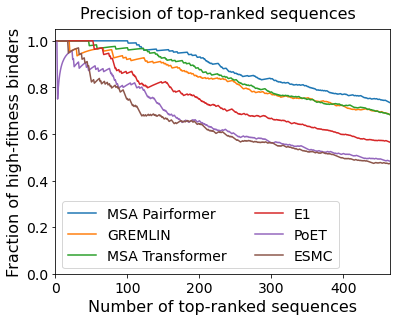

In [9]:
scores_paths_d = {
    "MSA Pairformer": "results/pseudolikelihood_l.msa_pairformer.qid30_id90.1024.npy",
    "GREMLIN": "results/toxin_antitoxin.gremlin.scores.txt",
    "MSA Transformer": "results/pseudolikelihood_l.msa_transformer.qid30_id90.npy",
    "E1": "results/e1_600m_toxin_antitoxin.tsv",
    "PoET": "results/poet_toxin_antitoxin_scores.npy",
    "ESMC": "results/pseudolikelihood_l.esmc_600m.npy",
}
plot_methods_l = [
    "MSA Pairformer",
    "GREMLIN",
    "MSA Transformer",
    "E1",
    "PoET",
    "ESMC",
]
fitness_l = (fitness_repA[1] + fitness_repB[1]) / 2
fitness_threshold = 0.15
k = np.sum(fitness_l >= fitness_threshold)
print(f"Number of high-fitness variants: {k}")
f, ax = plt.subplots(figsize=(6, 4.5))
for method in scores_paths_d:
    print(method)
    # Load scores
    if scores_paths_d[method].endswith(".npy"):
        scores_l = np.load(scores_paths_d[method])
    elif scores_paths_d[method].endswith(".tsv"):
        scores_l = pd.read_csv(scores_paths_d[method], sep='\t', index_col=0)['score']
    else:
        scores_l = np.loadtxt(scores_paths_d[method])
    # Rank variants by score
    top_k = np.argsort(scores_l)[::-1][:k]
    precision = np.sum(fitness_l[top_k] >= fitness_threshold) / k
    print(f"\tPrecision: {precision:.3f}")
    # Calculate AUPRC
    auprc = average_precision_score(fitness_l > fitness_threshold, scores_l)
    print(f"\tAUPRC: {auprc:.3f}")
    # Calculate Spearman rho
    spearman_rho = spearmanr(fitness_l, scores_l)[0]
    print(f"\tSpearman rho: {spearman_rho:.3f}")
    # Plot precision curve
    if method in plot_methods_l:
        precision_curve_a = np.cumsum(fitness_l[top_k] >= fitness_threshold) / np.arange(1, k + 1)
        ax.plot(np.arange(len(precision_curve_a)), precision_curve_a.tolist(), label=method)

ax.set_xlabel("Number of top-ranked sequences", size=16)
ax.set_ylabel("Fraction of high-fitness binders", size=16)
ax.tick_params(axis='both', labelsize=14)
f.suptitle("Precision of top-ranked sequences", size=16, y=0.95)
f.legend(fontsize=14, loc="lower left", bbox_to_anchor=(0.125, 0.12), ncol=2)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, k)

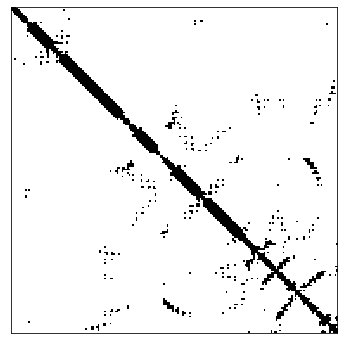

In [16]:
# CIF file path
cif_file_path = "../../data/Figure3_toxin_antitoxin/5CEG-assembly1.cif"

def get_cb_or_ca_coord(residue):
    """Return Cb coordinate, or Ca for glycine."""
    if residue.get_resname() == "GLY":
        return residue["CA"].get_vector().get_array()
    return residue["CB"].get_vector().get_array()


def get_residue_coord_dict(model, chain_id):
    """
    Return a dict mapping residue sequence number -> Cb/Ca coordinate.
    Skips hetero residues and residues missing the required atom.
    """
    chain = model[chain_id]
    coord_dict = {}
    for residue in chain.get_residues():
        if residue.id[0] != " ":
            continue
        resseq = residue.id[1]
        try:
            coord_dict[resseq] = get_cb_or_ca_coord(residue)
        except KeyError:
            continue
    return coord_dict


def _pairwise_distances(coords_dict_i, coords_dict_j, idx_map_i, idx_map_j):
    """
    Compute pairwise distances between two sets of residues and return
    (row_indices, col_indices, distances) for updating the distance map.
    """
    resseqs_i = list(coords_dict_i.keys())
    resseqs_j = list(coords_dict_j.keys())
    if not resseqs_i or not resseqs_j:
        return np.array([], dtype=int), np.array([], dtype=int), np.array([])

    arr_i = np.array([coords_dict_i[r] for r in resseqs_i])  # (Ni, 3)
    arr_j = np.array([coords_dict_j[r] for r in resseqs_j])  # (Nj, 3)
    dists = np.sqrt(((arr_i[:, None] - arr_j[None, :]) ** 2).sum(-1))  # (Ni, Nj)

    idxs_i = np.array([idx_map_i[r] for r in resseqs_i])
    idxs_j = np.array([idx_map_j[r] for r in resseqs_j])

    return idxs_i, idxs_j, dists


def extract_distance_map(cif_path, chains=("A", "B", "C", "D")):
    """
    Extract pairwise Cb-Cb (Ca for Gly) distance map from a CIF file.

    Chains A,C are copies of protein 1 (length L1).
    Chains B,D are copies of protein 2 (length L2).

    Returns:
        distance_map: (L1+L2, L1+L2) symmetric array, np.inf where unresolved
        resseq_1: sorted residue numbers for protein 1 (union of A and C)
        resseq_2: sorted residue numbers for protein 2 (union of B and D)
    """
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("struct", cif_path)
    model = structure[0]

    ch_a, ch_b, ch_c, ch_d = chains

    coords = {
        ch: get_residue_coord_dict(model, ch)
        for ch in [ch_a, ch_b, ch_c, ch_d]
    }

    resseq_1 = sorted(set(coords[ch_a]) | set(coords[ch_c]))
    resseq_2 = sorted(set(coords[ch_b]) | set(coords[ch_d]))

    L1 = len(resseq_1)
    L2 = len(resseq_2)
    L = L1 + L2

    idx_map_1 = {r: i for i, r in enumerate(resseq_1)}
    idx_map_2 = {r: L1 + j for j, r in enumerate(resseq_2)}

    distance_map = np.full((L, L), np.inf)

    def update_block(ch_i, ch_j, map_i, map_j):
        idxs_i, idxs_j, dists = _pairwise_distances(
            coords[ch_i], coords[ch_j], map_i, map_j
        )
        if len(idxs_i) == 0:
            return
        ix = np.ix_(idxs_i, idxs_j)
        distance_map[ix] = np.minimum(distance_map[ix], dists)
        # Symmetrize
        ix_t = np.ix_(idxs_j, idxs_i)
        distance_map[ix_t] = np.minimum(distance_map[ix_t], dists.T)

    # [:L1, :L1] — intra-monomer for protein 1 (A-A and C-C only)
    update_block(ch_a, ch_a, idx_map_1, idx_map_1)
    update_block(ch_c, ch_c, idx_map_1, idx_map_1)
    update_block(ch_a, ch_c, idx_map_1, idx_map_1)

    # [L1:, L1:] — intra-monomer for protein 2 (B-B and D-D only)
    update_block(ch_b, ch_b, idx_map_2, idx_map_2)
    update_block(ch_d, ch_d, idx_map_2, idx_map_2)
    update_block(ch_b, ch_d, idx_map_2, idx_map_2)

    # [:L1, L1:] and [L1:, :L1] — interface (A-B, A-D, C-B, C-D)
    update_block(ch_a, ch_b, idx_map_1, idx_map_2)
    update_block(ch_a, ch_d, idx_map_1, idx_map_2)
    update_block(ch_c, ch_b, idx_map_1, idx_map_2)
    update_block(ch_c, ch_d, idx_map_1, idx_map_2)

    return distance_map, resseq_1, resseq_2

distance_map, L1, L2 = extract_distance_map(cif_file_path)
contacts_a = distance_map < 8
f, ax = plt.subplots(1, 1, figsize=(6, 6), facecolor="white")
ax.imshow(contacts_a, cmap='Greys', interpolation='none', rasterized=True)
ax.set_xticks([])
ax.set_yticks([])

pard_seq = "MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGR"
pare_seq = "MAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF"
len_complex = len(pard_seq) + len(pare_seq)
pred_mask_a = np.ones((len_complex))
unresolved_residues_l = [0, 87, 88, 89, 90, 91, 92]
for unresolved_idx in unresolved_residues_l:
    pred_mask_a[unresolved_idx] = 0
pred_mask_a = pred_mask_a.astype(bool)

MSA Pairformer: 0.60, 0.00, 0.69
GREMLIN: 0.44, 0.00, 0.36
MSA Transformer: 0.43, 0.00, 0.40
E1: 0.02, 0.00, 0.65
ESMC: 0.02, 0.00, 0.61
PoET: 0.07, 0.00, 0.34


<Figure size 432x288 with 0 Axes>

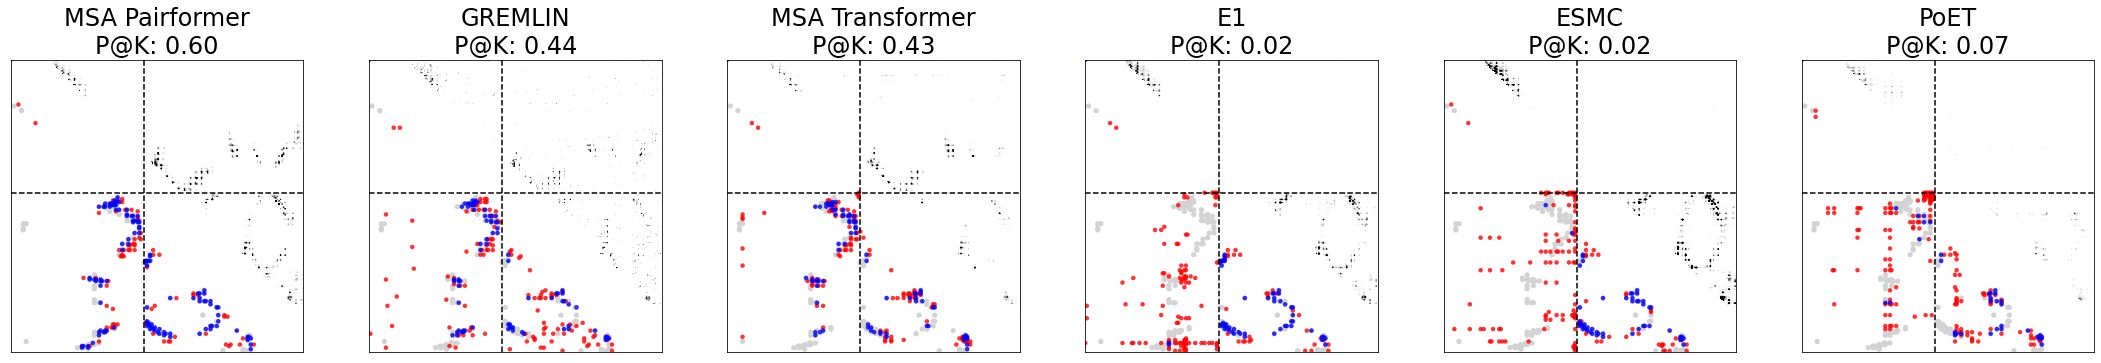

In [32]:
# Load GREMLIN contacts
gremlin_zscore_a = np.load("results/toxin_antitoxin.gremlin_contacts.zscore.npy")
gremlin_i_a = np.load("results/toxin_antitoxin.gremlin_contacts.i.npy")
gremlin_j_a = np.load("results/toxin_antitoxin.gremlin_contacts.j.npy")
gremlin_contacts_a = np.ones((196,196)) * np.nan
# populate
gremlin_contacts_a[gremlin_i_a,gremlin_j_a] = gremlin_zscore_a
gremlin_contacts_a[gremlin_j_a,gremlin_i_a] = gremlin_contacts_a[gremlin_i_a,gremlin_j_a]

# f, ax = plt.subplots(1, 6, figsize=(30, 5), sharey=True, facecolor="white")
plt.subplots_adjust(wspace=0.1)
methods_path_d = {
    "MSA Pairformer": "results/msa_pairformer_toxin_antitoxin_jacobian.txt",
    "GREMLIN": gremlin_contacts_a,
    "MSA Transformer": "results/msa_transformer_toxin_antitoxin_jacobian.txt",
    "E1": "results/e1_600m_toxin_antitoxin_jacobian.txt",
    "ESMC": "results/esmc_600m_casp15_catjac.txt",
    "PoET": "results/poet_toxin_antitoxin_jacobian.txt",
}
f, ax = plt.subplots(1, 6, figsize=(30, 5), sharey=True, facecolor="white")
plt.subplots_adjust(wspace=0.1)
chain_break_idx = 86
all_precision_d = {}
for i, (method, path) in enumerate(methods_path_d.items()):
    if method != "GREMLIN":
        if path.endswith(".npy"):
            pred = np.load(path)
        else:
            pred = np.loadtxt(path)
        vmin = 0
        vmax = 5
    else:
        vmax = 3
        vmin = 1
        pred = gremlin_contacts_a
    f, _, precision_d = eval_hetero_oligomer(
        cons = [contacts_a, pred[pred_mask_a][:, pred_mask_a]],
        chain_break_pos = chain_break_idx,
        L = 1,
        monomer_minsep = 24,
        cutoffs = [None, None],
        ss = [28, 20],
        cc = ['lightgray', 'blue'],
        f = f,
        ax = ax[i],
        vmax = vmax,
        vmin = vmin,
        monomer_p_at_k = True,
    )
    all_precision_d[method] = precision_d
    ax[i].set_title(f"{method}\nP@K: {precision_d['interface']:.2f}", size=24)
    ax[i].axvline(chain_break_idx, color="k", linestyle="--")
    ax[i].axhline(chain_break_idx, color="k", linestyle="--")
    print(f"{method}: {precision_d['interface']:.2f}, {precision_d['chain_0']:.2f}, {precision_d['chain_1']:.2f}")
f.tight_layout()